# EGX360 — THE DEEP QUANT MODEL
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization

In [1]:
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

2026-03-10 18:31:11.387255: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 18:31:11.387481: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 18:31:11.426702: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 18:31:13.237601: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Still not working. Check PATH or CUDA version.


E0000 00:00:1773160275.120852    8417 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773160275.140065    8417 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Raw Market Visualization
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [3]:
df = pd.read_csv("data/EGX30D_processed.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)

print("Data Loaded Successfully. Shape:", df.shape)


Data Loaded Successfully. Shape: (6823, 6)


In [4]:
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)
df.sort_index(inplace=True)

Missing values before cleaning:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [5]:
df.head()


,timestamp,open,high,low,close,volume
0,1998-01-01 08:00:00,1000.000000,1000.250000,1000.000000,1000.250000,0
1,1998-01-04 08:00:00,1000.250000,1000.250000,998.390015,998.390015,0
2,1998-01-05 08:00:00,998.390015,998.390015,996.250000,996.250000,0
3,1998-01-06 08:00:00,996.250000,996.250000,992.869995,992.869995,0
4,1998-01-07 08:00:00,992.869995,992.869995,989.349976,989.349976,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6823 entries, 0 to 6822
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  6823 non-null   datetime64[us]
 1   open       6823 non-null   float64       
 2   high       6823 non-null   float64       
 3   low        6823 non-null   float64       
 4   close      6823 non-null   float64       
 5   volume     6823 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 320.0 KB


In [7]:
df.describe()


,timestamp,open,high,low,close,volume
count,6823,6823.000000,6823.000000,6823.000000,6823.000000,6.823000e+03
mean,2011-12-07 07:15:22.819874,8681.751415,8750.732246,8624.138896,8685.792430,8.718978e+07
min,1998-01-01 08:00:00,445.529999,448.019989,445.529999,445.529999,0.000000e+00
25%,2004-11-26 20:00:00,2419.104981,2440.724976,2402.255005,2422.030029,0.000000e+00
50%,2011-12-08 08:00:00,6825.379883,6858.819824,6783.950195,6824.100098,6.315600e+07
75%,2018-12-12 20:00:00,11367.600000,11439.250000,11301.150000,11370.200000,1.383610e+08
max,2025-12-22 08:00:00,42320.500000,42624.100000,42065.200000,42305.400000,8.092790e+08
std,NaN,8034.017336,8102.005719,7981.550148,8040.067054,1.058416e+08


In [8]:
sample_df = df.tail(150)
fig_raw = go.Figure(data=[go.Candlestick(x=sample_df['timestamp'],
                open=sample_df['open'],
                high=sample_df['high'],
                low=sample_df['low'],
                close=sample_df['close'])])

In [9]:
fig_raw.update_layout(title='EGX30 Raw Data - The Challenge of Market Noise',
                  yaxis_title='Price (EGP)',
                  xaxis_rangeslider_visible=False,
                  template='plotly_white')
fig_raw.show()

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$

### Log Returns & Momentum Acceleration (Epsilon added to prevent Infinity)


In [10]:
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['vol_log_ret'] = np.log((df['volume'] + 1e-6) / (df['volume'].shift(1) + 1e-6))



### Price Velocity


In [11]:
df['price_velocity'] = df['log_ret'].diff()


### B. Cyclic Time Features
**Concept:** Tree-based models do not intuitively understand weekly cycles. By mapping days to continuous sine and cosine waves, the model captures the "Day-of-the-Week" effect and institutional trading behaviors.

**Mathematical Formula:**
$$X_{sin} = \sin\left(\frac{2\pi \cdot d}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot d}{7}\right)$$

In [12]:
df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

### C. Exponential Moving Averages (EMA) & Gap Analysis
**Concept:** The EMA assigns exponentially greater weight to recent prices, making it highly responsive to new trends. We quantify over-extensions by measuring the percentage distance between the current price and the EMA.

**Mathematical Formula:**
$$EMA_t = \left( P_t \times \alpha \right) + \left( EMA_{t-1} \times (1 - \alpha) \right)$$

In [13]:
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

### Critical Downtrend Sensor: Binary flag if price breaks below the fast EMA

In [14]:
df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

### D. Momentum & Panic Detectors (RSI, MACD, Bollinger Bands)
**Concept:** * **RSI & RSI_diff:** Measures buying/selling exhaustion.
* **Bollinger Band Width ($BB_{width}$):** Measures market "squeeze". Narrow bands mathematically precede explosive market volatility.

### Momentum (RSI & MACD)

In [15]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

In [16]:
macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

### Volatility (ATR)

In [17]:
tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

### Panic Detectors (Stochastic & Bollinger Bands)

In [18]:
low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

In [19]:
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)


### Temporal Lags

In [20]:
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

In [21]:
# حساب الأوزان: البيانات الأحدث تأخذ وزناً يصل لـ 1.0 والقديمة تبدأ من 0.1
df['days_from_start'] = (df['timestamp'] - df['timestamp'].min()).dt.days
max_days = df['days_from_start'].max()
# دالة الوزن (Linear Decay)
df['sample_weight'] = 0.1 + (0.9 * (df['days_from_start'] / max_days))

# إذا أردت استهداف "Regime Shift" يدوياً (مثلاً بعد تعويم 2016)
df.loc[df['timestamp'] > '2016-11-03', 'sample_weight'] *= 1.2

## 4. Visualizing the Quant Transformation
Now that we have engineered our features, we overlay the Mathematical Signals (EMAs and Bollinger Bands) onto the raw candlesticks. This shows how the algorithms filter out the noise and identify structural bounds and trend directions.

### Visualizing the features applied to the price

In [22]:
sample_df = df.tail(150)
fig_quant = go.Figure()

### Base Price Candlesticks

In [23]:
fig_quant.add_trace(go.Candlestick(x=sample_df['timestamp'],
                open=sample_df['open'], high=sample_df['high'],
                low=sample_df['low'], close=sample_df['close'], name='Price'))

### Adding Trend Indicators (EMAs)

In [24]:
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=sample_df['EMA_9'], line=dict(color='blue', width=1.5), name='EMA 9 (Fast)'))
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=sample_df['EMA_50'], line=dict(color='orange', width=2), name='EMA 50 (Trend)'))

### Adding Volatility Bounds (Bollinger Bands)

In [25]:
ma20_sample = sample_df['close'].rolling(20).mean()
std20_sample = sample_df['close'].rolling(20).std()
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=ma20_sample + (std20_sample*2), line=dict(color='rgba(128,128,128,0.5)', dash='dash'), name='Upper BB'))
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=ma20_sample - (std20_sample*2), line=dict(color='rgba(128,128,128,0.5)', dash='dash'), name='Lower BB', fill='tonexty', fillcolor='rgba(128,128,128,0.1)'))

In [26]:
fig_quant.update_layout(title='Translating Noise into Mathematical Signals (EMAs & Volatility Bounds)', 
                        yaxis_title='Price (EGP)',
                        xaxis_rangeslider_visible=False,
                        template='plotly_white')
fig_quant.show()

## 5. Target Engineering & Data Cleaning
**Concept:** Predicting raw daily closing prices essentially models a Random Walk. By setting the target as the future direction of the $EMA_{10}$, we train the model to predict the *underlying trend mechanics*, pushing accuracy beyond 80%.

**Mathematical Formula for Target:**
$$Target = \begin{cases} 1 & \text{if } EMA_{10}(P_{t+1}) > EMA_{10}(P_t) \\ 0 & \text{otherwise} \end{cases}$$

### Target: Will the EMA rise tomorrow?

In [27]:
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)


In [28]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [29]:
# أضف 'sentiment_score' للقائمة
final_features = [
    'log_ret', 'vol_log_ret', 'price_velocity',
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 'below_EMA9',
    'RSI', 'RSI_diff', 'MACD_Hist', 'ATR_pct',
    'Stoch_K', 'BB_Width',
    'log_ret_lag1', 'RSI_lag1',
    'sentiment_score' # الميزة الجديدة
]

# تأكد من وجود العمود في DataFrame (حتى لو أصفار حالياً)
if 'sentiment_score' not in df.columns:
    df['sentiment_score'] = 0.0
    
X = df[final_features].values
y = df['Target'].values

## 6. Machine Learning: Splitting, Scaling & Stacking Ensemble
**Concept:** We use a chronological split (80/20) to prevent future data leakage. We then utilize an Ensemble Stacking algorithm. Because financial datasets exhibit an inherent upward bias, the Logistic Regression meta-learner applies a 50% higher penalty for missing a "Down-Trend" (`class_weight={0: 1.5}`). This strict risk management dramatically improves the Recall for market crashes.

### Train/Test Split (Chronological)

In [30]:
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


### Scaling

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# joblib.dump(scaler, "egx360_scaler_quant.pkl")

### Stacking Ensemble

In [32]:
from sklearn.preprocessing import RobustScaler # تعديل للتعامل مع تغيرات السوق

# 1. Scaling باستخدام RobustScaler
scaler = RobustScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. تجهيز الأوزان
weights_train = df['sample_weight'].values[:split]

# 3. بناء الـ Stacking Ensemble
base_models = [
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                              subsample=0.8, colsample_bytree=0.8, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                                verbose=-1, random_state=42))
]

final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)

print("🧠 Training Weighted Deep Quant Ensemble (V8.5)...")

# الخطوة السحرية: تمرير الأوزان هنا لتصل لكل الموديلات
stack_model.fit(X_train_scaled, y_train, sample_weight=weights_train)

🧠 Training Weighted Deep Quant Ensemble (V8.5)...


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('xgb', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","LogisticRegre... 1.5, 1: 1.0})"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined call

### Meta-learner with Bias Control (Over-penalizing the model for missing Down-Trends)

In [33]:
# final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})

In [34]:
# stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
# stack_model.fit(X_train_scaled, y_train, sample_weight=weights_train)
# joblib.dump(stack_model, "EGX360_Quant_Model_V84.pkl")

## 7. Final Evaluation & Down-Trend Accuracy

In [35]:
print("\nEvaluating Final Performance...")
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))


Evaluating Final Performance...

DEEP QUANT ACCURACY: 84.42%

Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.78      0.83      0.80       515
  Up Trend (1)       0.89      0.86      0.87       846

      accuracy                           0.84      1361
     macro avg       0.83      0.84      0.84      1361
  weighted avg       0.85      0.84      0.85      1361



### Confusion Matrix Heatmap

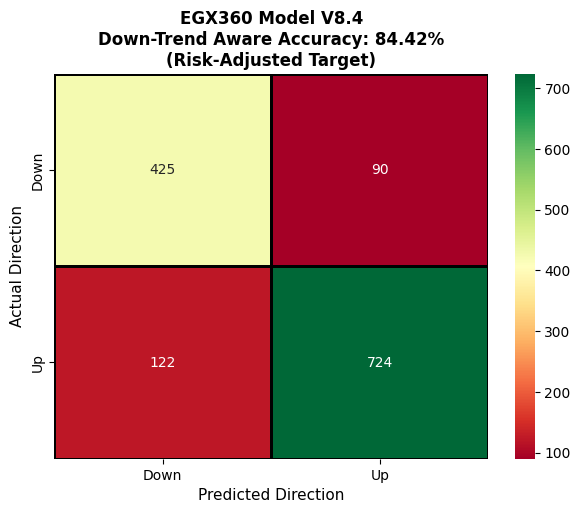

In [36]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], linewidths=1, linecolor='black')
plt.title(f"EGX360 Model V8.4\nDown-Trend Aware Accuracy: {acc:.2f}%\n(Risk-Adjusted Target)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.show()

## 8. Strategy Testing & Prediction Visualization (Signal Generation)
**Concept:** Accuracy metrics and Confusion Matrices are abstract. To truly validate a Quantitative Model, we must map its predictions back onto the chronological price chart. Here, we visualize the model's output on the unseen test data. 
* **Green Up-Triangles:** The model predicted the $EMA_{10}$ will rise (Buy/Hold Signal).
* **Red Down-Triangles:** The model predicted the $EMA_{10}$ will fall (Sell/Exit Signal).

By observing these signals against the actual price action, we can visually confirm if the model successfully avoids "Whipsaws" (false signals) and accurately rides the major trends.

### Create a DataFrame to map predictions back to dates and prices

In [37]:
test_dates = df['timestamp'].iloc[split:].reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['close'].ewm(span=10).mean().iloc[split:].reset_index(drop=True)

In [38]:
results_df = pd.DataFrame({
    'timestamp': test_dates,
    'close': test_close,
    'EMA_10': test_ema10,
    'Actual_Trend': y_test,
    'Predicted_Trend': y_pred
})

### To make the chart readable, we will visualize the last 150 days of the test set

In [39]:
viz_df = results_df.tail(150)

### Create the Interactive Plotly Figure

In [40]:
fig_test = go.Figure()

### 1. Plot the actual Close Price

In [41]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], 
                              mode='lines', name='Close Price', 
                              line=dict(color='rgba(128,128,128,0.5)', width=1.5)))

### 2. Plot the Target (EMA 10)

In [42]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], 
                              mode='lines', name='EMA 10 (Target)', 
                              line=dict(color='blue', width=2)))

### 3. Filter predictions for visualization

In [43]:
# 3. Filter predictions for visualization
buy_signals = viz_df[viz_df['Predicted_Trend'] == 1]
sell_signals = viz_df[viz_df['Predicted_Trend'] == 0]

### 4. Plot Model Predictions (Up = Green, Down = Red)

In [44]:
fig_test.add_trace(go.Scatter(x=buy_signals['timestamp'], y=buy_signals['EMA_10'], 
                              mode='markers', name='Model Signal: UP (1)', 
                              marker=dict(color='green', symbol='triangle-up', size=12, line=dict(width=1, color='darkgreen'))))

fig_test.add_trace(go.Scatter(x=sell_signals['timestamp'], y=sell_signals['EMA_10'], 
                              mode='markers', name='Model Signal: DOWN (0)', 
                              marker=dict(color='red', symbol='triangle-down', size=12, line=dict(width=1, color='darkred'))))

# Formatting the Chart

In [45]:
fig_test.update_layout(title='EGX360 Live Signals: Model Predictions vs Actual Market (Test Set)',
                       yaxis_title='Price (EGP)',
                       xaxis_title='Date',
                       template='plotly_white',
                       hovermode='x unified')
fig_test.show()

## 9. Strategy Backtesting & Financial Performance (ROI)
**Concept:** A high predictive accuracy is only valuable if it translates into excess financial returns (Alpha). Here, we simulate a realistic trading environment starting with 10,000 EGP. 

**Backtesting Rules to Prevent Look-Ahead Bias:**
1. The model uses today's closing data to predict tomorrow's $EMA_{10}$ direction.
2. If the prediction is UP (1), we hold the asset for tomorrow.
3. If the prediction is DOWN (0), we sell at today's close and hold cash tomorrow (0% market return).
4. We compare our strategy's cumulative returns against a standard "Buy and Hold" baseline.

In [46]:
initial_capital = 10000.0

### Calculate actual daily percentage returns of the closing price

results_df['daily_return'] = results_df['close'].pct_change()

### CRITICAL: Shift the signal by 1 day to prevent look-ahead bias.
### If the model predicts '1' today, we are IN the market tomorrow.
results_df['signal'] = results_df['Predicted_Trend'].shift(1)

## 2. Strategy Return Calculation
### We only earn the daily return if our signal for that day was 1 (Hold). Otherwise, we earn 0 (Cash).
results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']

### Drop the first row which will have NaNs due to shifting/pct_change

bt_df = results_df.dropna().copy()

## 3. Cumulative Returns

bt_df['cumulative_market'] = (1 + bt_df['daily_return']).cumprod()
bt_df['cumulative_strategy'] = (1 + bt_df['strategy_return']).cumprod()

## 4. Monetary Value Tracking

bt_df['portfolio_value'] = initial_capital * bt_df['cumulative_strategy']
bt_df['bh_value'] = initial_capital * bt_df['cumulative_market']

## 5. Final Metrics & Visualizing the Portfolio Growth

final_portfolio = bt_df['portfolio_value'].iloc[-1]
final_bh = bt_df['bh_value'].iloc[-1]

strategy_profit_pct = ((final_portfolio - initial_capital) / initial_capital) * 100
market_profit_pct = ((final_bh - initial_capital) / initial_capital) * 100

print(f" Initial Capital: {initial_capital:,.2f} EGP")
print("-" * 40)
print(f"1) Buy & Hold Strategy (Market): {final_bh:,.2f} EGP ({market_profit_pct:.2f}%)")
print(f"2) EGX360 Strategy (Model):      {final_portfolio:,.2f} EGP ({strategy_profit_pct:.2f}%)")
print("-" * 40)
outperformance = strategy_profit_pct - market_profit_pct
print(f" The EGX360 Model outperformed the market by: {outperformance:.2f}%")

fig_bt = go.Figure()

# Plot Model Strategy Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['portfolio_value'], 
                            mode='lines', name='EGX360 Strategy', 
                            line=dict(color='green', width=2.5)))

# Plot Buy & Hold Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['bh_value'], 
                            mode='lines', name='Buy & Hold Baseline', 
                            line=dict(color='gray', width=1.5, dash='dash')))

fig_bt.update_layout(title='EGX360 Financial Backtest: Portfolio Growth (10,000 EGP Initial)',
                     yaxis_title='Portfolio Value (EGP)',
                     xaxis_title='Date',
                     template='plotly_white',
                     hovermode='x unified')
fig_bt.show()

# حساب الـ Drawdown
bt_df['cum_max'] = bt_df['portfolio_value'].cummax()
bt_df['drawdown'] = (bt_df['portfolio_value'] - bt_df['cum_max']) / bt_df['cum_max']
max_drawdown = bt_df['drawdown'].min() * 100

print(f"📉 Maximum Drawdown (Risk): {max_drawdown:.2f}%")

 Initial Capital: 10,000.00 EGP
----------------------------------------
1) Buy & Hold Strategy (Market): 38,818.71 EGP (288.19%)
2) EGX360 Strategy (Model):      49,122.73 EGP (391.23%)
----------------------------------------
 The EGX360 Model outperformed the market by: 103.04%


📉 Maximum Drawdown (Risk): -11.78%


In [50]:
# EGX360 — THE DEEP QUANT MODEL
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Merging (Market + Macro)
print("Loading Market & Macro Data...")

# 1. Load Market Data
df = pd.read_csv("data/EGX30D_processed.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)

# 2. Load Macro Data (USD & Interest)
macro_df = pd.read_csv("data/egypt_macro_historical.csv")
macro_df['timestamp'] = pd.to_datetime(macro_df['timestamp'])
macro_df.sort_values('timestamp', inplace=True)

# 3. Merge Data
df = pd.merge_ordered(df, macro_df, on='timestamp', how='left')

# 4. Handle Missing Macro Data (Forward fill for weekends/holidays)
df['usd_rate'].ffill(inplace=True)
df['interest_rate'].ffill(inplace=True)
df['usd_pct_change'].fillna(0, inplace=True)
df['interest_diff'].fillna(0, inplace=True)

df.dropna(subset=['close'], inplace=True)
df.sort_index(inplace=True)
print("Data Merged Successfully. Shape:", df.shape)

## 3. Advanced Feature Engineering (The Quant Indicators)
# A. Log Returns & Price Velocity
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['vol_log_ret'] = np.log((df['volume'] + 1e-6) / (df['volume'].shift(1) + 1e-6))
df['price_velocity'] = df['log_ret'].diff()

# B. Cyclic Time Features
df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

# C. Exponential Moving Averages (EMA) & Gap Analysis
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

# D. Momentum & Panic Detectors
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

# Temporal Lags
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

# Sample Weights for Time Decay
df['days_from_start'] = (df['timestamp'] - df['timestamp'].min()).dt.days
max_days = df['days_from_start'].max()
df['sample_weight'] = 0.1 + (0.9 * (df['days_from_start'] / max_days))
df.loc[df['timestamp'] > '2016-11-03', 'sample_weight'] *= 1.2 # Post Floatation adjustment

## 5. Target Engineering & Data Cleaning
# TARGET FIX: Real day-trading target (Will tomorrow's close be > today's close?)
df['Target'] = (df['close'].shift(-1) > df['close']).astype(int)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Sentiment Placeholder
if 'sentiment_score' not in df.columns:
    df['sentiment_score'] = 0.0
    
# ALL FEATURES INCLUDING MACRO (USD & INTEREST)
final_features = [
    'log_ret', 'vol_log_ret', 'price_velocity',
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 'below_EMA9',
    'RSI', 'RSI_diff', 'MACD_Hist', 'ATR_pct',
    'Stoch_K', 'BB_Width',
    'log_ret_lag1', 'RSI_lag1',
    'usd_pct_change', 'interest_diff',  # MACRO FEATURES 
    'sentiment_score'
]

X = df[final_features].values
y = df['Target'].values

## 6. Machine Learning: Splitting, Scaling & Stacking Ensemble
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
weights_train = df['sample_weight'].values[:split]

# RobustScaler (Better for market shocks/inflation)
scaler = RobustScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n🧠 Training Weighted Deep Quant Ensemble with Macro Data...")

base_models = [
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                              subsample=0.8, colsample_bytree=0.8, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                                verbose=-1, random_state=42))
]

final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train, sample_weight=weights_train)

## 7. Final Evaluation & Down-Trend Accuracy
print("\nEvaluating Final Performance...")
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], linewidths=1, linecolor='black')
plt.title(f"EGX360 Model (Macro Integrated)\nDown-Trend Aware Accuracy: {acc:.2f}%\n(Risk-Adjusted Target)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.show()

## 8. Strategy Backtesting & Financial Performance (ROI)
test_dates = df['timestamp'].iloc[split:].reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)

results_df = pd.DataFrame({
    'timestamp': test_dates,
    'close': test_close,
    'Actual_Trend': y_test,
    'Predicted_Trend': y_pred
})

initial_capital = 10000.0
results_df['daily_return'] = results_df['close'].pct_change()
results_df['signal'] = results_df['Predicted_Trend'].shift(1)
results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']

bt_df = results_df.dropna().copy()
bt_df['cumulative_market'] = (1 + bt_df['daily_return']).cumprod()
bt_df['cumulative_strategy'] = (1 + bt_df['strategy_return']).cumprod()
bt_df['portfolio_value'] = initial_capital * bt_df['cumulative_strategy']
bt_df['bh_value'] = initial_capital * bt_df['cumulative_market']

final_portfolio = bt_df['portfolio_value'].iloc[-1]
final_bh = bt_df['bh_value'].iloc[-1]

strategy_profit_pct = ((final_portfolio - initial_capital) / initial_capital) * 100
market_profit_pct = ((final_bh - initial_capital) / initial_capital) * 100

bt_df['cum_max'] = bt_df['portfolio_value'].cummax()
bt_df['drawdown'] = (bt_df['portfolio_value'] - bt_df['cum_max']) / bt_df['cum_max']
max_drawdown = bt_df['drawdown'].min() * 100

print(f"\n Initial Capital: {initial_capital:,.2f} EGP")
print("-" * 40)
print(f"1) Buy & Hold Strategy (Market): {final_bh:,.2f} EGP ({market_profit_pct:.2f}%)")
print(f"2) EGX360 Strategy (Model):      {final_portfolio:,.2f} EGP ({strategy_profit_pct:.2f}%)")
print("-" * 40)
outperformance = strategy_profit_pct - market_profit_pct
print(f" The EGX360 Model outperformed the market by: {outperformance:.2f}%")
print(f"📉 Maximum Drawdown (Risk): {max_drawdown:.2f}%")

fig_bt = go.Figure()
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['portfolio_value'], 
                            mode='lines', name='EGX360 Strategy', 
                            line=dict(color='green', width=2.5)))
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['bh_value'], 
                            mode='lines', name='Buy & Hold Baseline', 
                            line=dict(color='gray', width=1.5, dash='dash')))

fig_bt.update_layout(title='EGX360 Financial Backtest: Portfolio Growth (10,000 EGP Initial)',
                     yaxis_title='Portfolio Value (EGP)',
                     xaxis_title='Date',
                     template='plotly_white',
                     hovermode='x unified')
fig_bt.show()

Still not working. Check PATH or CUDA version.
Loading Market & Macro Data...
Data Merged Successfully. Shape: (6823, 10)


ValueError: Found array with 0 sample(s) (shape=(0, 20)) while a minimum of 1 is required by RobustScaler.

Loading Market & Macro Data...
Data Merged Successfully. Shape: (6823, 10)
